## Does match duration differ by surface?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
IN_DIR = "cleaned_data"

event = pd.read_parquet(f'{IN_DIR}/event.parquet')
time_df = pd.read_parquet(f'{IN_DIR}/time.parquet')
hts = pd.read_parquet(f'{IN_DIR}/home_team_score.parquet')
ats = pd.read_parquet(f'{IN_DIR}/away_team_score.parquet')
tourn = pd.read_parquet(f'{IN_DIR}/tournament.parquet')

In [3]:
# Same reliability + pace cross-check pipeline established for Q4/Q11
time_df_ok = time_df[time_df['duration_minutes'].between(15,300)].copy()
ev = event[event['score_ready'] & ~event['is_retirement_like']].copy()
m = time_df.merge(ev[['match_id', 'match_completed']], on='match_id', how='left')
base = m[(m['duration_reliable']) & (m['match_completed'] == True)].copy()
set_cols = ['period_1', 'period_2', 'period_3']
games = (hts[['match_id'] + set_cols].merge(ats[['match_id'] + set_cols], on='match_id', suffixes=('_h', '_a')))
games['total_games'] = games[[c for c in games.columns if c.startswith('period')]].sum(axis=1)
base = base.merge(games[['match_id', 'total_games']], on='match_id', how='left')
base = base[base['total_games'] > 0]
base['sec_per_game'] = base['duration_seconds'] / base['total_games']

In [4]:
family_map = {
    'Hardcourt outdoor': 'Hard', 'Hardcourt indoor': 'Hard',
    'Red clay': 'Clay', 'Red clay indoor': 'Clay', 'Green clay': 'Clay',
    'Grass': 'Grass', 'Carpet indoor': 'Carpet', 'Synthetic outdoor': 'Synthetic',
}

In [5]:
tourn['surface_family'] = tourn['ground_type'].map(family_map)
clean = base.merge(tourn[['match_id', 'surface_family']], on='match_id', how='left').dropna(subset=['surface_family'])
clean['minutes'] = clean['duration_seconds'] / 60

In [6]:
order = clean.groupby('surface_family')['minutes'].median().sort_values(ascending=False).index.tolist()
data = [clean.loc[clean.surface_family == s, 'minutes'].values for s in order]
counts = [len(d) for d in data]

In [7]:
print("Median duration by surface:")
print(clean.groupby('surface_family')['minutes'].agg(['median', 'mean', 'count']).loc[order])

Median duration by surface:
                    median        mean  count
surface_family                               
Clay            100.800000  108.212024   3206
Grass            97.983333  102.184211    152
Synthetic        95.433333  107.359430     76
Hard             94.633333  101.720657   6316
Carpet           88.183333   97.790541    111


C:\Users\QR\AppData\Local\Temp\ipykernel_15228\316938745.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[f"{s}\n(n={n})" for s, n in zip(order, counts)],


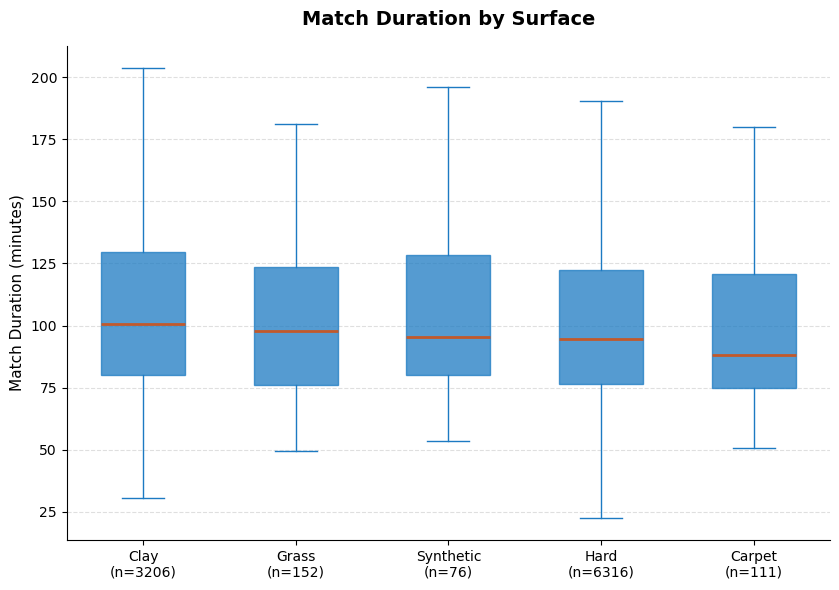

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 6))
bp = ax.boxplot(data, labels=[f"{s}\n(n={n})" for s, n in zip(order, counts)],
                 patch_artist=True, showfliers=False, widths=0.55,
                 medianprops=dict(color='#C1592C', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor("#1C7AC2")
    patch.set_alpha(0.75)
    patch.set_edgecolor("#1C7AC2")
for element in ['whiskers', 'caps']:
    for line in bp[element]:
        line.set_color("#1C7AC2")
 
ax.set_ylabel('Match Duration (minutes)', fontsize=11)
ax.set_title('Match Duration by Surface', fontsize=14, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('charts\demo1_duration_by_surface.png', dpi=200, bbox_inches='tight')

Observation: Same 15–300 minute / reliability / completion filters as Q4–Q11. Median minutes: Clay 100.8 (n=3,206), Grass 98.0 (n=152), Synthetic 95.4 (n=76), Hard 94.6 (n=6,316), Carpet 88.2 (n=111). Outliers hidden (showfliers=False).

Interpretation: Clay–Hard median gap is ~6 minutes. Grass / Synthetic / Carpet samples are much smaller, so those medians are less stable; Clay vs Hard is the only large-sample contrast.

Limitation: Hidden outliers mean tails by surface are not visible here.